In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
"""
Phase A, Step 1 — Auto-generate entity extraction training pairs from your
existing synthetic records. No manual labeling needed here: the structured
JSON fields you already have ARE the gold labels.

Run this in Colab, in the same environment where industrial_records.json lives.
"""

import json
import os
import re

def synthetic_records_to_training_pairs(json_path):
    """Each record becomes one (input_text, gold_entities) pair."""
    with open(json_path, 'r', encoding='utf-8') as f:
        data = json.load(f)

    pairs = []
    for category in ['maintenance_logs', 'incident_reports', 'work_permits']:
        for item in data.get(category, []):
            # Build the input text the same way ingestion does — the model
            # should learn to extract from what it will actually see at inference.
            input_text = "\n".join([f"Record Type: {category}"] + [f"{k}: {v}" for k, v in item.items()])

            gold_entities = {
                "equipment_id": item.get("equipment_id"),
                "date": item.get("date") or (item.get("date_range", "").split(" to ")[0] if "date_range" in item else None),
                "record_type": category,
                "record_id": item.get("log_id") or item.get("incident_id") or item.get("permit_id"),
                "person_role": item.get("technician_role") or item.get("approving_officer"),
                "location": item.get("location"),
            }
            # Drop null fields — the model shouldn't be trained to predict "null"
            gold_entities = {k: v for k, v in gold_entities.items() if v is not None}

            pairs.append({"input_text": input_text, "gold_entities": gold_entities, "source": "synthetic"})

    return pairs


if __name__ == "__main__":
    base_path = "/content/drive/MyDrive/ET_Industrial_data"
    json_path = os.path.join(base_path, "synthetic", "industrial_records.json")

    pairs = synthetic_records_to_training_pairs(json_path)
    print(f"✅ Generated {len(pairs)} labeled pairs from synthetic records — zero manual labeling.")
    print("\n--- Sample pair ---")
    print(json.dumps(pairs[0], indent=2))

    out_path = os.path.join(base_path, "entity_training", "synthetic_pairs.json")
    os.makedirs(os.path.dirname(out_path), exist_ok=True)
    json.dump(pairs, open(out_path, 'w', encoding='utf-8'), indent=2)
    print(f"\n💾 Saved to {out_path}")

✅ Generated 50 labeled pairs from synthetic records — zero manual labeling.

--- Sample pair ---
{
  "input_text": "Record Type: maintenance_logs\nlog_id: M-101\nequipment_id: PUMP-14\ndate: 2026-06-10\nissue: Severe vibration and bearing noise.\nresolution: Replaced thrust bearing and realigned shaft.\ntechnician_role: Maintenance Tech",
  "gold_entities": {
    "equipment_id": "PUMP-14",
    "date": "2026-06-10",
    "record_type": "maintenance_logs",
    "record_id": "M-101",
    "person_role": "Maintenance Tech"
  },
  "source": "synthetic"
}

💾 Saved to /content/drive/MyDrive/ET_Industrial_data/entity_training/synthetic_pairs.json


In [2]:
#step 2
import os
import json
import re

# ---------------------------------------------------------
# 1. SETUP & KNOWN LISTS
# ---------------------------------------------------------
BASE_PATH = "/content/drive/MyDrive/ET_Industrial_data"
INPUT_CHUNKS_PATH = os.path.join(BASE_PATH, "master_chunks.json")
OUTPUT_DIR = os.path.join(BASE_PATH, "entity_training")
OUTPUT_PAIRS_PATH = os.path.join(OUTPUT_DIR, "regulatory_weak_pairs.json")

os.makedirs(OUTPUT_DIR, exist_ok=True)

KNOWN_HAZARDS = [
    "Flammable Gas", "High Pressure", "Mechanical",
    "Thermal/Heat", "Toxic/Asphyxiant Gas", "Confined Space", "Chemical Leak",
    "Electrical", "Fire/Dust"
]

HAZARD_SYNONYMS = {
    "fume": ["Toxic/Asphyxiant Gas", "Flammable Gas"],
    "gas": ["Toxic/Asphyxiant Gas", "Flammable Gas"],
    "fencing": ["Mechanical"],
    "machinery": ["Mechanical"],
    "dust": ["Fire/Dust", "Toxic/Asphyxiant Gas"],
    "pressure": ["High Pressure"],
    "temperature": ["Thermal/Heat"],
    "heat": ["Thermal/Heat"],
    "confined": ["Confined Space"]
}

# ---------------------------------------------------------
# 2. STRICT WEAK LABELING LOGIC
# ---------------------------------------------------------
def clean_text(text):
    """Strip HTML/OCR comments and extra whitespace."""
    text = re.sub(r'<!--.*?-->', '', text, flags=re.DOTALL)
    return text.strip()

def extract_dates(text):
    pattern = r'\b(?:\d{1,2}[-/]\d{1,2}[/-]\d{2,4}|\d{4}[-/]\d{1,2}[/-]\d{1,2}|(?:Jan(?:uary)?|Feb(?:ruary)?|Mar(?:ch)?|Apr(?:il)?|May|Jun(?:e)?|Jul(?:y)?|Aug(?:ust)?|Sep(?:tember)?|Oct(?:ober)?|Nov(?:ember)?|Dec(?:ember)?)\s+\d{1,2},?\s+\d{4})\b'
    return list(set(re.findall(pattern, text)))

def extract_section(text, metadata):
    # Regex explicitly captures numbers followed by optional letters (e.g. "41A.")
    title = metadata.get("section_title", "")
    match = re.search(r'^(\d+[A-Z]?)\b', title)
    if match:
        return match.group(1)

    fallback_match = re.search(r'(?:^|\n)\*\*?(\d+[A-Z]?)\.\s*', text)
    if fallback_match:
        return fallback_match.group(1)

    return None

def weak_label_chunk(chunk):
    raw_text = chunk.get("text", "")
    metadata = chunk.get("metadata", {})

    clean_txt = clean_text(raw_text)

    # Pre-filter: If the chunk is empty after stripping OCR garbage, skip processing
    if len(clean_txt) < 10:
        return None

    # 1. Section Number
    section_num = extract_section(clean_txt, metadata)

    # 2. Strict Boundary Hazard Mentions
    found_hazards = set()
    for haz in KNOWN_HAZARDS:
        if re.search(rf'\b{re.escape(haz)}\b', clean_txt, re.IGNORECASE):
            found_hazards.add(haz)

    for keyword, mapped_hazards in HAZARD_SYNONYMS.items():
        if re.search(rf'\b{re.escape(keyword)}\b', clean_txt, re.IGNORECASE):
            for mapped_haz in mapped_hazards:
                found_hazards.add(mapped_haz)

    dates = extract_dates(clean_txt)
    source_doc = metadata.get("source", "UNKNOWN")

    return {
        "input_text": clean_txt,
        "gold_entities": {
            "section_number": section_num,
            "hazard_mentions": list(found_hazards),
            "dates": dates,
            "source_document": source_doc
        },
        "source": "regulatory_weak_label",
        "chunk_id": metadata.get("chunk_id", "UNKNOWN")
    }

# ---------------------------------------------------------
# 3. EXECUTION
# ---------------------------------------------------------
if __name__ == "__main__":
    with open(INPUT_CHUNKS_PATH, 'r', encoding='utf-8') as f:
        all_chunks = json.load(f)

    regulatory_chunks = [c for c in all_chunks if c.get("metadata", {}).get("doc_type") == "regulatory"]

    weak_pairs = []
    chunks_with_hazards = 0

    for chunk in regulatory_chunks:
        pair = weak_label_chunk(chunk)
        if pair:
            weak_pairs.append(pair)
            if pair["gold_entities"]["hazard_mentions"]:
                chunks_with_hazards += 1

    with open(OUTPUT_PAIRS_PATH, 'w', encoding='utf-8') as f:
        json.dump(weak_pairs, f, ensure_ascii=False, indent=2)

In [4]:
!pip install -q -U transformers peft bitsandbytes accelerate datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 87.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 555.1/555.1 kB 44.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 17.1 MB/s eta 0:00:00


In [7]:
"""
Phase B — Fine-tune a small entity extraction model (LoRA, 4-bit, Colab T4).

Builds on Phase A's labeled data:
  - synthetic_pairs.json        (50 pairs, clean gold labels)
  - regulatory_weak_pairs.json  (460 pairs: 155 "thick" w/ hazards, 305 "thin")

Run this in Colab. Install deps first:
  !pip install -q -U transformers peft bitsandbytes accelerate datasets

MODEL CHOICE: Qwen2.5-1.5B-Instruct (ungated). If you have approved Llama 3.2
access instead, change MODEL_ID below to "meta-llama/Llama-3.2-1B-Instruct"
and make sure you're logged in via `huggingface-cli login` / notebook_login().
"""

import os
import json
import random

import torch
from datasets import Dataset
from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
    BitsAndBytesConfig,
    TrainingArguments,
    Trainer,
    DataCollatorForSeq2Seq,
    TrainerCallback,
)
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training

# ---------------------------------------------------------
# 0. CONFIG
# ---------------------------------------------------------
SEED = 42
random.seed(SEED)

MODEL_ID = "Qwen/Qwen2.5-1.5B-Instruct"  # default per instructions; swap if Llama approved

BASE_PATH = "/content/drive/MyDrive/ET_Industrial_data"
SYNTHETIC_PATH = os.path.join(BASE_PATH, "entity_training", "synthetic_pairs.json")
REGULATORY_PATH = os.path.join(BASE_PATH, "entity_training", "regulatory_weak_pairs.json")
HELD_OUT_PATH = os.path.join(BASE_PATH, "entity_training", "held_out.json")
ADAPTER_DIR = os.path.join(BASE_PATH, "entity_model", "lora_adapter")

INSTRUCTION = (
    "Extract structured entities from this industrial document text. "
    "Return valid JSON only."
)

MAX_LEN = 1024

os.makedirs(os.path.dirname(HELD_OUT_PATH), exist_ok=True)
os.makedirs(ADAPTER_DIR, exist_ok=True)

# ---------------------------------------------------------
# 1. LOAD + BALANCE DATA
# ---------------------------------------------------------
with open(SYNTHETIC_PATH, "r", encoding="utf-8") as f:
    synthetic_pairs = json.load(f)

with open(REGULATORY_PATH, "r", encoding="utf-8") as f:
    regulatory_pairs = json.load(f)

thick = [p for p in regulatory_pairs if p["gold_entities"].get("hazard_mentions")]
thin = [p for p in regulatory_pairs if not p["gold_entities"].get("hazard_mentions")]

print(f"Synthetic: {len(synthetic_pairs)} | Regulatory thick: {len(thick)} | Regulatory thin: {len(thin)}")

rng = random.Random(SEED)
thin_capped = rng.sample(thin, min(len(thick), len(thin)))

all_pairs = synthetic_pairs + thick + thin_capped
print(f"Combined dataset: {len(all_pairs)} pairs "
      f"({len(synthetic_pairs)} synthetic + {len(thick)} thick + {len(thin_capped)} sampled thin)")

# ---------------------------------------------------------
# 2. SPLIT 80/20 BEFORE ANY FURTHER PROCESSING
# ---------------------------------------------------------
shuffled = all_pairs[:]
rng.shuffle(shuffled)

split_idx = int(len(shuffled) * 0.8)
train_pairs = shuffled[:split_idx]
held_out_pairs = shuffled[split_idx:]

print(f"Train: {len(train_pairs)} | Held-out: {len(held_out_pairs)}")

with open(HELD_OUT_PATH, "w", encoding="utf-8") as f:
    json.dump(held_out_pairs, f, ensure_ascii=False, indent=2)
print(f"Saved held-out set -> {HELD_OUT_PATH}")

# ---------------------------------------------------------
# 3. TOKENIZER + PROMPT FORMATTING
# ---------------------------------------------------------
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token


def build_prompt(input_text):
    """Chat-formatted prompt up to (but not including) the assistant's answer."""
    messages = [
        {"role": "system", "content": INSTRUCTION},
        {"role": "user", "content": input_text},
    ]
    return tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )


def tokenize_pair(pair):
    """Tokenize prompt+answer, masking the prompt portion so loss is only
    computed on the JSON output (standard instruction-tuning practice)."""
    prompt = build_prompt(pair["input_text"])
    answer = json.dumps(pair["gold_entities"], ensure_ascii=False) + tokenizer.eos_token

    prompt_ids = tokenizer(prompt, add_special_tokens=False)["input_ids"]
    answer_ids = tokenizer(answer, add_special_tokens=False)["input_ids"]

    input_ids = prompt_ids + answer_ids
    labels = [-100] * len(prompt_ids) + answer_ids

    input_ids = input_ids[:MAX_LEN]
    labels = labels[:MAX_LEN]

    return {
        "input_ids": input_ids,
        "attention_mask": [1] * len(input_ids),
        "labels": labels,
    }


train_dataset = Dataset.from_list([tokenize_pair(p) for p in train_pairs])

# ---------------------------------------------------------
# 4. LOAD MODEL IN 4-BIT
# ---------------------------------------------------------
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
)

model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map="auto",
)
model = prepare_model_for_kbit_training(model)

# ---------------------------------------------------------
# 5. LoRA CONFIG (Qwen2 attention + MLP proj names)
# ---------------------------------------------------------
lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
    target_modules=[
        "q_proj", "k_proj", "v_proj", "o_proj",
        "gate_proj", "up_proj", "down_proj",
    ],
)

model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

# ---------------------------------------------------------
# 6. TRAINING
# ---------------------------------------------------------
data_collator = DataCollatorForSeq2Seq(
    tokenizer=tokenizer, model=model, padding=True, label_pad_token_id=-100
)


class EpochLossPrinter(TrainerCallback):
    """Prints mean training loss at the end of each epoch."""
    def on_log(self, args, state, control, logs=None, **kwargs):
        if logs and "loss" in logs:
            print(f"  step {state.global_step} | loss: {logs['loss']:.4f}")

    def on_epoch_end(self, args, state, control, **kwargs):
        print(f"--- Epoch {state.epoch:.0f} complete ---")


training_args = TrainingArguments(
    output_dir="/content/phase_b_checkpoints",
    per_device_train_batch_size=2,
    gradient_accumulation_steps=4,  # effective batch size 8
    num_train_epochs=4,
    learning_rate=2e-4,
    fp16=True,
    logging_steps=1,
    save_strategy="no",
    report_to="none",
    seed=SEED,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    data_collator=data_collator,
    callbacks=[EpochLossPrinter()],
)

trainer.train()

# ---------------------------------------------------------
# 7. SAVE LoRA ADAPTER ONLY
# ---------------------------------------------------------
model.save_pretrained(ADAPTER_DIR)
tokenizer.save_pretrained(ADAPTER_DIR)
print(f"LoRA adapter saved -> {ADAPTER_DIR}")

# ---------------------------------------------------------
# 8. SANITY CHECK ON 3 HELD-OUT EXAMPLES (not training data)
# ---------------------------------------------------------
model.eval()
sample_check = rng.sample(held_out_pairs, min(3, len(held_out_pairs)))

print("\n" + "=" * 70)
print("SANITY CHECK — generation on held-out examples")
print("=" * 70)

for i, pair in enumerate(sample_check, 1):
    prompt = build_prompt(pair["input_text"])
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

    with torch.no_grad():
        output_ids = model.generate(
            **inputs,
            max_new_tokens=256,
            do_sample=False,
            temperature=None,
            top_p=None,
            pad_token_id=tokenizer.pad_token_id,
        )

    generated = tokenizer.decode(
        output_ids[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True
    )

    print(f"\n--- Example {i} ---")
    print(f"INPUT TEXT:\n{pair['input_text'][:500]}")
    print(f"\nGOLD ENTITIES:\n{json.dumps(pair['gold_entities'], indent=2)}")
    print(f"\nMODEL OUTPUT (raw):\n{generated}")

    try:
        parsed = json.loads(generated.strip())
        print("\n[valid JSON parsed OK]")
    except json.JSONDecodeError as e:
        print(f"\n[NOT valid JSON — {e}]")

print("\nPhase B complete. Stopping here — precision/recall scoring is Phase C.")

Synthetic: 50 | Regulatory thick: 155 | Regulatory thin: 305
Combined dataset: 360 pairs (50 synthetic + 155 thick + 155 sampled thin)
Train: 288 | Held-out: 72
Saved held-out set -> /content/drive/MyDrive/ET_Industrial_data/entity_training/held_out.json


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


trainable params: 18,464,768 || all params: 1,562,179,072 || trainable%: 1.1820


/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1263: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Step,Training Loss
1,3.046739
2,2.456828
3,1.489815
4,1.730997
5,1.421396
6,0.963057
7,0.727930
8,0.462204
9,0.463432
10,0.460683


  step 1 | loss: 3.0467
  step 2 | loss: 2.4568
  step 3 | loss: 1.4898
  step 4 | loss: 1.7310
  step 5 | loss: 1.4214
  step 6 | loss: 0.9631
  step 7 | loss: 0.7279
  step 8 | loss: 0.4622
  step 9 | loss: 0.4634
  step 10 | loss: 0.4607
  step 11 | loss: 0.2939
  step 12 | loss: 0.3408
  step 13 | loss: 0.2354
  step 14 | loss: 0.3336
  step 15 | loss: 0.1437
  step 16 | loss: 0.3070
  step 17 | loss: 0.2453
  step 18 | loss: 0.1436
  step 19 | loss: 0.1354
  step 20 | loss: 0.1624
  step 21 | loss: 0.2484
  step 22 | loss: 0.1653
  step 23 | loss: 0.2215
  step 24 | loss: 0.0879
  step 25 | loss: 0.1430
  step 26 | loss: 0.1044
  step 27 | loss: 0.0719
  step 28 | loss: 0.0857
  step 29 | loss: 0.1253
  step 30 | loss: 0.1111
  step 31 | loss: 0.0487
  step 32 | loss: 0.0513
  step 33 | loss: 0.0671
  step 34 | loss: 0.2729
  step 35 | loss: 0.0827
  step 36 | loss: 0.0430
--- Epoch 1 complete ---
  step 37 | loss: 0.0567
  step 38 | loss: 0.0868
  step 39 | loss: 0.0423
  step 40

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)



--- Example 1 ---
INPUT TEXT:
. 

7. It shall be ensured that the entire process area and/or drilling area is kept under intrinsically safe effective CCTV surveillance to monitor all operations closely. Recording of all such surveillance shall be stored for a period of at least 30 days. Before deleting the data, it shall be examined for unsafe act/practice. If any abnormality is observed, the same shall be rectified and 

. recorded in a bound paged book kept for the purpose. 8. Record of every inspection, testing, examinati

GOLD ENTITIES:
{
  "section_number": null,
  "hazard_mentions": [
    "Mechanical"
  ],
  "dates": [],
  "source_document": "dgms_2020_05_oil_gas_safety.pdf"
}

MODEL OUTPUT (raw):
{"section_number": null, "hazard_mentions": ["Mechanical"], "dates": [], "source_document": "oisd-gdn-207.pdf"}

[valid JSON parsed OK]

--- Example 2 ---
INPUT TEXT:
|15.7|Whether<br>minimum<br>occupancy<br>of<br>the<br>premises<br>/ workplace<br>is being ensured<br>while radiography 

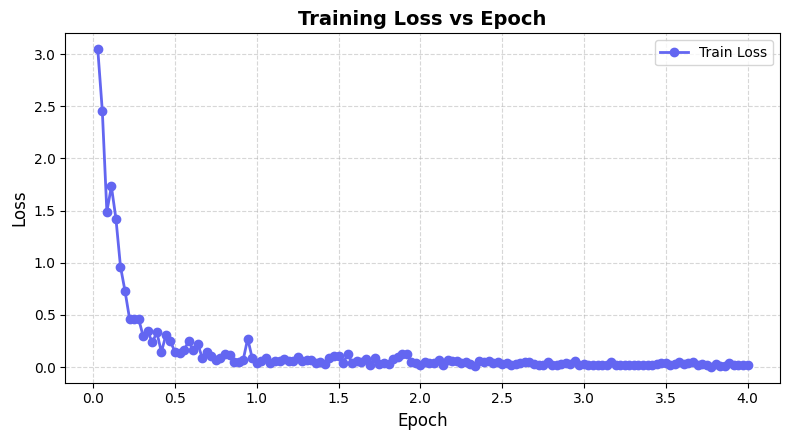

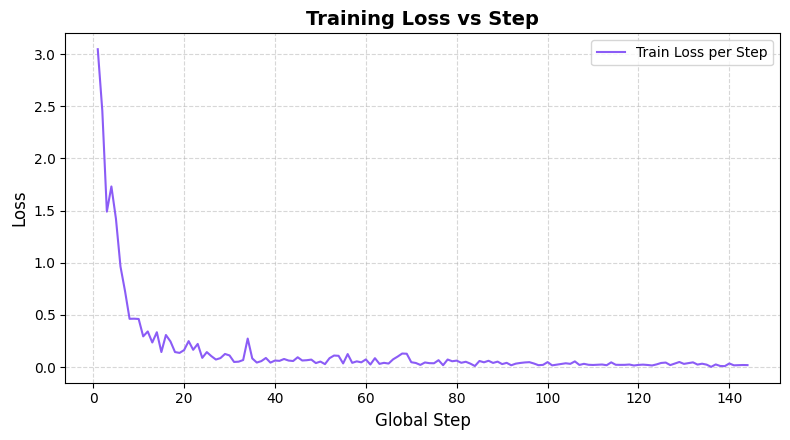

In [8]:
import matplotlib.pyplot as plt
import pandas as pd

# Extract log history directly from your Hugging Face trainer
log_history = trainer.state.log_history

# Convert to DataFrame
df = pd.DataFrame(log_history)

# Filter for rows that actually recorded training loss
if 'loss' in df.columns:
    loss_df = df.dropna(subset=['loss']).copy()

    # --- PLOT 1: LOSS VS EPOCH ---
    plt.figure(figsize=(8, 4.5))
    plt.plot(loss_df['epoch'], loss_df['loss'], marker='o', color='#6366f1', linewidth=2, label='Train Loss')
    plt.title('Training Loss vs Epoch', fontsize=14, fontweight='bold')
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('Loss', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # --- PLOT 2: LOSS VS STEP (Higher Resolution) ---
    plt.figure(figsize=(8, 4.5))
    plt.plot(loss_df['step'], loss_df['loss'], color='#8b5cf6', linewidth=1.5, label='Train Loss per Step')
    plt.title('Training Loss vs Step', fontsize=14, fontweight='bold')
    plt.xlabel('Global Step', fontsize=12)
    plt.ylabel('Loss', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print("⚠️ No loss values found in trainer state history.")

In [5]:
"""
Phase B QA follow-up — run in Colab before Phase C evaluation begins.

Fixes two issues found in the sanity check:
  1. `source_document` is not inferable from input_text and was causing the
     model to hallucinate filenames. It's known deterministically from chunk
     metadata at inference time, so it should never have been a prediction
     target for scoring purposes.
  2. Some "thick" weak-labels (hazard_mentions non-empty) may be false
     positives from the Phase A regex/synonym matching — e.g. "Mechanical"
     firing on CCTV/record-keeping text that mentions "machinery" only in
     passing, with no real mechanical-hazard content.

This script does NOT retrain the model. It only:
  (a) defines the field exclusion for Phase C's precision/recall calc, and
  (b) surfaces a sample of thick held-out labels for you to manually confirm
      or reject, then applies whatever corrections you approve.
"""

import os
import re
import json
import random
import shutil

# ---------------------------------------------------------
# 0. CONFIG
# ---------------------------------------------------------
SEED = 42
BASE_PATH = "/content/drive/MyDrive/ET_Industrial_data"
HELD_OUT_PATH = os.path.join(BASE_PATH, "entity_training", "held_out.json")
HELD_OUT_BACKUP_PATH = os.path.join(BASE_PATH, "entity_training", "held_out_pre_qa_backup.json")

# Same vocab used in Phase A's weak-labeling, reused here only to locate
# *where* each hazard label's evidence sits in the text for review context —
# not to re-derive labels.
KNOWN_HAZARDS = [
    "Flammable Gas", "High Pressure", "Mechanical",
    "Thermal/Heat", "Toxic/Asphyxiant Gas", "Confined Space", "Chemical Leak",
    "Electrical", "Fire/Dust"
]
HAZARD_SYNONYMS = {
    "fume": ["Toxic/Asphyxiant Gas", "Flammable Gas"],
    "gas": ["Toxic/Asphyxiant Gas", "Flammable Gas"],
    "fencing": ["Mechanical"],
    "machinery": ["Mechanical"],
    "dust": ["Fire/Dust", "Toxic/Asphyxiant Gas"],
    "pressure": ["High Pressure"],
    "temperature": ["Thermal/Heat"],
    "heat": ["Thermal/Heat"],
    "confined": ["Confined Space"],
}
# Terms that suggest the chunk is administrative/procedural rather than
# actually describing a hazard — used only as a heuristic to prioritize
# what to look at first, not as a final verdict.
ADMIN_CONTEXT_WORDS = [
    "cctv", "surveillance", "record", "register", "log book", "signature",
    "form no", "attendance", "muster", "notice board", "filing",
]

random.seed(SEED)

# ---------------------------------------------------------
# 1. FIELD EXCLUSION FOR PHASE C SCORING
# ---------------------------------------------------------
EXCLUDED_FIELDS_FROM_SCORING = {"source_document"}


def filter_for_scoring(entities: dict) -> dict:
    """Apply this to BOTH gold and predicted entities before computing
    precision/recall in Phase C. source_document is known from chunk
    metadata at inference time and was never a fair prediction target."""
    return {k: v for k, v in entities.items() if k not in EXCLUDED_FIELDS_FROM_SCORING}


# quick demo of the effect, not a real scoring run
_demo_gold = {"section_number": "41A", "hazard_mentions": ["Mechanical"],
              "dates": ["Jan 4, 2020"], "source_document": "factories_act_1948.pdf"}
print("Example — before filtering:", _demo_gold)
print("Example — after filtering: ", filter_for_scoring(_demo_gold))
print(f"\nPhase C scoring must call filter_for_scoring() on both gold_entities "
      f"and model output before computing precision/recall. Field(s) dropped: "
      f"{EXCLUDED_FIELDS_FROM_SCORING}\n")

# ---------------------------------------------------------
# 2. LOAD HELD-OUT SET AND ISOLATE "THICK" ENTRIES
# ---------------------------------------------------------
with open(HELD_OUT_PATH, "r", encoding="utf-8") as f:
    held_out = json.load(f)

thick_entries = [p for p in held_out if p.get("gold_entities", {}).get("hazard_mentions")]
print(f"Held-out set: {len(held_out)} total | {len(thick_entries)} thick (hazard_mentions non-empty)")

N_AUDIT = min(20, len(thick_entries))
audit_sample = random.sample(thick_entries, N_AUDIT)
print(f"Auditing {N_AUDIT} thick held-out entries (seed={SEED}, reproducible)\n")


# ---------------------------------------------------------
# 3. HEURISTIC PRE-SCREEN (surfaces candidates — does not decide)
# ---------------------------------------------------------
def find_context(text, keyword, window=60):
    """Return a snippet around the first case-insensitive match of keyword."""
    m = re.search(rf'\b{re.escape(keyword)}\b', text, re.IGNORECASE)
    if not m:
        return None
    start = max(0, m.start() - window)
    end = min(len(text), m.end() + window)
    return f"...{text[start:end]}..."


def evidence_terms_for_hazard(hazard):
    """All literal words that could have triggered this hazard label."""
    terms = [hazard] if hazard in KNOWN_HAZARDS else []
    terms += [kw for kw, mapped in HAZARD_SYNONYMS.items() if hazard in mapped]
    return terms


def heuristic_flag(pair):
    """Returns (is_flagged, reasons[]) — a starting point for manual review,
    not a final verdict. Flags on: (a) hazard evidence co-occurring with
    admin/procedural vocabulary, or (b) only a single sparse mention in a
    long chunk (weak signal-to-noise)."""
    text = pair["input_text"]
    text_lower = text.lower()
    reasons = []

    admin_hit = next((w for w in ADMIN_CONTEXT_WORDS if w in text_lower), None)

    for hazard in pair["gold_entities"]["hazard_mentions"]:
        terms = evidence_terms_for_hazard(hazard)
        match_count = sum(len(re.findall(rf'\b{re.escape(t)}\b', text, re.IGNORECASE)) for t in terms)

        if admin_hit and match_count <= 1:
            reasons.append(
                f"'{hazard}': only {match_count} mention(s), alongside admin/procedural "
                f"term '{admin_hit}' — possible false positive"
            )
        elif match_count == 1 and len(text) > 800:
            reasons.append(
                f"'{hazard}': single sparse mention in a long ({len(text)}-char) chunk — "
                f"check whether it's incidental"
            )

    return (len(reasons) > 0, reasons)


# ---------------------------------------------------------
# 4. PRINT AUDIT RESULTS
# ---------------------------------------------------------
flagged = []
clean = []

for pair in audit_sample:
    is_flagged, reasons = heuristic_flag(pair)
    if is_flagged:
        flagged.append((pair, reasons))
    else:
        clean.append(pair)

print("=" * 70)
print(f"FLAGGED FOR REVIEW — {len(flagged)} / {N_AUDIT}")
print("=" * 70)

for pair, reasons in flagged:
    print(f"\nchunk_id: {pair.get('chunk_id')}")
    print(f"hazard_mentions: {pair['gold_entities']['hazard_mentions']}")
    print("heuristic reasons:")
    for r in reasons:
        print(f"  - {r}")
    print("evidence context:")
    for hazard in pair["gold_entities"]["hazard_mentions"]:
        for term in evidence_terms_for_hazard(hazard):
            ctx = find_context(pair["input_text"], term)
            if ctx:
                print(f"  [{hazard} <- '{term}'] {ctx}")
    print(f"full text ({len(pair['input_text'])} chars):")
    print(f"  {pair['input_text'][:600]}{'...' if len(pair['input_text']) > 600 else ''}")

print("\n" + "=" * 70)
print(f"NOT FLAGGED (auto-check passed) — {len(clean)} / {N_AUDIT}")
print("=" * 70)
for pair in clean:
    print(f"  chunk_id: {pair.get('chunk_id')} | hazards: {pair['gold_entities']['hazard_mentions']}")

flag_rate = len(flagged) / N_AUDIT
print(f"\nHeuristic flag rate: {flag_rate:.0%} of audited thick entries "
      f"({len(flagged)}/{N_AUDIT})")
if flag_rate >= 0.15:
    print("This meets/exceeds the ~15-20% threshold — recommend manually confirming "
          "the flagged entries above, then running the correction step below.")
else:
    print("Below the ~15-20% threshold based on the heuristic pre-screen — still worth "
          "a quick manual read of the flagged list, but likely fine to proceed to Phase C "
          "once you've eyeballed it.")

# ---------------------------------------------------------
# 5. APPLY CORRECTIONS (manual step — fill in after reviewing output above)
# ---------------------------------------------------------
# After reading the FLAGGED section, decide the fate of each chunk_id:
#   - "remove"  -> drop the entry from held_out.json entirely
#   - "correct" -> keep the entry but fix its hazard_mentions list
#
# Example (edit this dict based on your actual review, then run this cell):
#
# REVIEW_DECISIONS = {
#     "chunk_142": "remove",
#     "chunk_87": {"correct": []},              # no real hazard content
#     "chunk_203": {"correct": ["Mechanical"]},  # keep only the valid label
# }

REVIEW_DECISIONS = {
    "chunk_429": "remove",
    "chunk_60": "remove",
    "chunk_245": "remove",
    "chunk_254": "remove",
    "chunk_44": "remove",
    "chunk_436": {"correct": ["Mechanical"]},
    "chunk_232": {"correct": ["Toxic/Asphyxiant Gas", "Fire/Dust"]},
    "chunk_259": {"correct": []},  # borderline — drop this line if you'd rather keep it
}  # <-- fill this in after manual review, then re-run this cell

if REVIEW_DECISIONS:
    shutil.copy(HELD_OUT_PATH, HELD_OUT_BACKUP_PATH)
    print(f"Backed up original held-out set -> {HELD_OUT_BACKUP_PATH}")

    corrected = []
    for pair in held_out:
        cid = pair.get("chunk_id")
        decision = REVIEW_DECISIONS.get(cid)
        if decision == "remove":
            continue
        if isinstance(decision, dict) and "correct" in decision:
            pair["gold_entities"]["hazard_mentions"] = decision["correct"]
        corrected.append(pair)

    with open(HELD_OUT_PATH, "w", encoding="utf-8") as f:
        json.dump(corrected, f, ensure_ascii=False, indent=2)

    print(f"Applied {len(REVIEW_DECISIONS)} correction(s). "
          f"Held-out set: {len(held_out)} -> {len(corrected)} entries.")
    print(f"Saved -> {HELD_OUT_PATH}")
else:
    print("\nREVIEW_DECISIONS is empty — no changes applied. Fill it in based on the "
          "flagged output above, then re-run this script's section 5 to apply corrections.")

Example — before filtering: {'section_number': '41A', 'hazard_mentions': ['Mechanical'], 'dates': ['Jan 4, 2020'], 'source_document': 'factories_act_1948.pdf'}
Example — after filtering:  {'section_number': '41A', 'hazard_mentions': ['Mechanical'], 'dates': ['Jan 4, 2020']}

Phase C scoring must call filter_for_scoring() on both gold_entities and model output before computing precision/recall. Field(s) dropped: {'source_document'}

Held-out set: 67 total | 24 thick (hazard_mentions non-empty)
Auditing 20 thick held-out entries (seed=42, reproducible)

FLAGGED FOR REVIEW — 11 / 20

chunk_id: chunk_101
hazard_mentions: ['Mechanical', 'Toxic/Asphyxiant Gas', 'High Pressure', 'Thermal/Heat', 'Flammable Gas']
heuristic reasons:
  - 'Mechanical': single sparse mention in a long (1403-char) chunk — check whether it's incidental
  - 'Thermal/Heat': single sparse mention in a long (1403-char) chunk — check whether it's incidental
evidence context:
  [Mechanical <- 'machinery'] ...of this sub-se

In [1]:
"""
Phase C — Evaluate + integrate the fine-tuned entity extractor.

Run in Colab. Requires:
  !pip install -q -U transformers peft bitsandbytes accelerate

Depends on:
  - LoRA adapter saved at .../entity_model/lora_adapter/ (Phase B)
  - Cleaned held_out.json (Phase B QA follow-up — 67 entries, source_document
    excluded from scoring, false-positive hazard labels corrected/removed)

Produces:
  - Per-entity-type precision/recall/F1 -> entity_model/phase_c_metrics.json
  - Raw predictions for inspection      -> entity_model/phase_c_predictions.json
  - extract_entities() — drop-in replacement for the hardcoded
    EQUIPMENT_HAZARDS / REGULATORY_HAZARDS dicts used at ingestion time
  - A live-demo call on a document with no hardcoded mapping
"""

import os
import json
import re

import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from peft import PeftModel

# ---------------------------------------------------------
# 0. CONFIG
# ---------------------------------------------------------
BASE_PATH = "/content/drive/MyDrive/ET_Industrial_data"
BASE_MODEL_ID = "Qwen/Qwen2.5-1.5B-Instruct"  # must match whatever Phase B actually trained
ADAPTER_DIR = os.path.join(BASE_PATH, "entity_model", "lora_adapter")
HELD_OUT_PATH = os.path.join(BASE_PATH, "entity_training", "held_out.json")
METRICS_OUT_PATH = os.path.join(BASE_PATH, "entity_model", "phase_c_metrics.json")
PREDICTIONS_OUT_PATH = os.path.join(BASE_PATH, "entity_model", "phase_c_predictions.json")

INSTRUCTION = (
    "Extract structured entities from this industrial document text. "
    "Return valid JSON only."
)

# Same exclusion as the QA follow-up — applied consistently to gold AND prediction
EXCLUDED_FIELDS_FROM_SCORING = {"source_document"}

# Fields whose values are lists (compared as sets) vs. scalars (compared as strings)
LIST_FIELDS = {"hazard_mentions", "dates"}

MAX_NEW_TOKENS = 256

# ---------------------------------------------------------
# 1. LOAD BASE MODEL + LoRA ADAPTER (4-bit, inference only)
# ---------------------------------------------------------
tokenizer = AutoTokenizer.from_pretrained(ADAPTER_DIR)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
)

base_model = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL_ID, quantization_config=bnb_config, device_map="auto"
)
model = PeftModel.from_pretrained(base_model, ADAPTER_DIR)
model.eval()

print(f"Loaded base model {BASE_MODEL_ID} + LoRA adapter from {ADAPTER_DIR}")


# ---------------------------------------------------------
# 2. INFERENCE HELPER
# ---------------------------------------------------------
def build_prompt(input_text):
    messages = [
        {"role": "system", "content": INSTRUCTION},
        {"role": "user", "content": input_text},
    ]
    return tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)


def generate_entities(input_text):
    """Returns (parsed_dict_or_None, raw_generated_string)."""
    prompt = build_prompt(input_text)
    inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=1024).to(model.device)

    with torch.no_grad():
        output_ids = model.generate(
            **inputs,
            max_new_tokens=MAX_NEW_TOKENS,
            do_sample=False,
            pad_token_id=tokenizer.pad_token_id,
        )

    raw = tokenizer.decode(output_ids[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True).strip()

    # Model may wrap JSON in a code fence despite instructions — strip defensively
    cleaned = re.sub(r'^```(?:json)?|```$', '', raw, flags=re.MULTILINE).strip()

    try:
        parsed = json.loads(cleaned)
        if not isinstance(parsed, dict):
            return None, raw
        return parsed, raw
    except json.JSONDecodeError:
        return None, raw


def filter_for_scoring(entities: dict) -> dict:
    return {k: v for k, v in entities.items() if k not in EXCLUDED_FIELDS_FROM_SCORING}


# ---------------------------------------------------------
# 3. RUN INFERENCE ON HELD-OUT SET
# ---------------------------------------------------------
with open(HELD_OUT_PATH, "r", encoding="utf-8") as f:
    held_out = json.load(f)

print(f"Running inference on {len(held_out)} held-out examples...")

results = []
invalid_json_count = 0

for i, pair in enumerate(held_out):
    parsed, raw = generate_entities(pair["input_text"])
    if parsed is None:
        invalid_json_count += 1
    results.append({
        "chunk_id": pair.get("chunk_id", pair.get("source", f"idx_{i}")),
        "input_text": pair["input_text"],
        "gold_entities": pair["gold_entities"],
        "predicted_entities": parsed if parsed is not None else {},
        "predicted_raw": raw,
        "json_valid": parsed is not None,
    })
    if (i + 1) % 10 == 0:
        print(f"  {i + 1}/{len(held_out)} done")

json_validity_rate = 1 - (invalid_json_count / len(held_out))
print(f"\nJSON validity rate: {json_validity_rate:.1%} "
      f"({len(held_out) - invalid_json_count}/{len(held_out)} parsed as valid JSON)")
print("(Invalid-JSON examples are scored as a complete miss on every gold field below —"
      " a low validity rate will drag recall down independent of field accuracy.)")

with open(PREDICTIONS_OUT_PATH, "w", encoding="utf-8") as f:
    json.dump(results, f, ensure_ascii=False, indent=2)
print(f"Saved raw predictions -> {PREDICTIONS_OUT_PATH}")

# ---------------------------------------------------------
# 4. PER-ENTITY-TYPE PRECISION / RECALL / F1
# ---------------------------------------------------------
def normalize_scalar(v):
    return str(v).strip().lower() if v is not None else None


field_stats = {}  # field_name -> {"tp": int, "fp": int, "fn": int}


def bump(field, tp=0, fp=0, fn=0):
    s = field_stats.setdefault(field, {"tp": 0, "fp": 0, "fn": 0})
    s["tp"] += tp
    s["fp"] += fp
    s["fn"] += fn


for r in results:
    gold = filter_for_scoring(r["gold_entities"])
    pred = filter_for_scoring(r["predicted_entities"])
    all_keys = set(gold.keys()) | set(pred.keys())

    for key in all_keys:
        if key in LIST_FIELDS:
            gold_set = set(gold.get(key) or [])
            pred_set = set(pred.get(key) or [])
            bump(key, tp=len(gold_set & pred_set), fp=len(pred_set - gold_set), fn=len(gold_set - pred_set))
        else:
            g = normalize_scalar(gold.get(key))
            p = normalize_scalar(pred.get(key))
            if g is not None and p is not None:
                if g == p:
                    bump(key, tp=1)
                else:
                    bump(key, fp=1, fn=1)
            elif g is not None and p is None:
                bump(key, fn=1)
            elif g is None and p is not None:
                bump(key, fp=1)
            # both None: field not applicable to this example, skip


def prf1(tp, fp, fn):
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
    return precision, recall, f1


print("\n" + "=" * 70)
print("PER-ENTITY-TYPE METRICS (held-out set, n={})".format(len(held_out)))
print("=" * 70)
print(f"{'field':22s} {'precision':>10s} {'recall':>10s} {'f1':>10s} {'support':>9s}")

metrics_summary = {}
total_tp = total_fp = total_fn = 0

for field in sorted(field_stats.keys()):
    s = field_stats[field]
    p, r, f1 = prf1(s["tp"], s["fp"], s["fn"])
    support = s["tp"] + s["fn"]  # gold-positive count
    print(f"{field:22s} {p:10.2%} {r:10.2%} {f1:10.2%} {support:9d}")
    metrics_summary[field] = {"precision": p, "recall": r, "f1": f1, "support": support,
                               "tp": s["tp"], "fp": s["fp"], "fn": s["fn"]}
    total_tp += s["tp"]
    total_fp += s["fp"]
    total_fn += s["fn"]

micro_p, micro_r, micro_f1 = prf1(total_tp, total_fp, total_fn)
print("-" * 70)
print(f"{'MICRO-AVG (all fields)':22s} {micro_p:10.2%} {micro_r:10.2%} {micro_f1:10.2%} {total_tp + total_fn:9d}")

metrics_summary["_overall_micro"] = {
    "precision": micro_p, "recall": micro_r, "f1": micro_f1,
    "tp": total_tp, "fp": total_fp, "fn": total_fn,
}
metrics_summary["_json_validity_rate"] = json_validity_rate

with open(METRICS_OUT_PATH, "w", encoding="utf-8") as f:
    json.dump(metrics_summary, f, ensure_ascii=False, indent=2)
print(f"\nSaved metrics -> {METRICS_OUT_PATH}")

# ---------------------------------------------------------
# 5. WIRE INTO INGESTION — replaces the hardcoded
#    EQUIPMENT_HAZARDS / REGULATORY_HAZARDS dict lookups
# ---------------------------------------------------------
def extract_entities(chunk: dict) -> dict:
    """
    Drop-in replacement for the Phase A hardcoded-dict / regex weak-labeling
    approach. Takes a chunk in the same shape used during ingestion
    ({"text": ..., "metadata": {...}}) and returns entities via the
    fine-tuned model, with source_document attached deterministically from
    metadata (never predicted — see Phase B QA follow-up).
    """
    text = chunk.get("text", "")
    metadata = chunk.get("metadata", {})

    parsed, raw = generate_entities(text)
    if parsed is None:
        # graceful fallback: don't break ingestion on a bad generation,
        # surface it instead so it can be logged/reviewed
        parsed = {"_extraction_failed": True, "_raw_output": raw}

    parsed["source_document"] = metadata.get("source", "UNKNOWN")  # deterministic, not model-predicted
    parsed["chunk_id"] = metadata.get("chunk_id", "UNKNOWN")
    return parsed


# ---------------------------------------------------------
# 6. LIVE DEMO — a document with no hardcoded mapping
# ---------------------------------------------------------
# None of these equipment IDs/phrasing appear in EQUIPMENT_HAZARDS,
# REGULATORY_HAZARDS, KNOWN_EQUIPMENTS, or the training data — this is the
# "updates automatically as new records arrive" moment for the demo.
demo_chunk = {
    "text": (
        "Maintenance Log — Unit REACTOR-R7\n"
        "Date: 14/03/2026\n"
        "Technician: J. Fernandes (Senior Mechanical Fitter)\n"
        "Observation: Recurrent vibration detected on the agitator shaft "
        "bearing housing during routine inspection. Isolated per LOTO "
        "procedure before opening the housing. No gas leakage or pressure "
        "anomaly observed during the isolation window. Bearing replaced; "
        "unit returned to service after function test."
    ),
    "metadata": {
        "source": "unit_r7_maintenance_log_2026_03.pdf",
        "chunk_id": "demo_new_doc_001",
        "doc_type": "maintenance",
    },
}

print("\n" + "=" * 70)
print("LIVE DEMO — document never seen at training or hardcoded-mapping time")
print("=" * 70)
print("INPUT:\n" + demo_chunk["text"])
demo_result = extract_entities(demo_chunk)
print("\nEXTRACTED ENTITIES:")
print(json.dumps(demo_result, indent=2))

model.safetensors: reconstructing file:   0%|          |  0.00B / 3.09GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

Loaded base model Qwen/Qwen2.5-1.5B-Instruct + LoRA adapter from /content/drive/MyDrive/ET_Industrial_data/entity_model/lora_adapter
Running inference on 67 held-out examples...


/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


  10/67 done
  20/67 done
  30/67 done
  40/67 done
  50/67 done
  60/67 done

JSON validity rate: 100.0% (67/67 parsed as valid JSON)
(Invalid-JSON examples are scored as a complete miss on every gold field below — a low validity rate will drag recall down independent of field accuracy.)
Saved raw predictions -> /content/drive/MyDrive/ET_Industrial_data/entity_model/phase_c_predictions.json

PER-ENTITY-TYPE METRICS (held-out set, n=67)
field                   precision     recall         f1   support
date                      100.00%    100.00%    100.00%        13
dates                     100.00%    100.00%    100.00%         9
equipment_id              100.00%    100.00%    100.00%        13
hazard_mentions            45.28%     53.33%     48.98%        45
location                  100.00%    100.00%    100.00%         4
person_role               100.00%    100.00%    100.00%         9
record_id                 100.00%    100.00%    100.00%        13
record_type               100.0